# Proyecto 7 - Explorando factores de comportamiento en NovaRetail+



NovaRetail+ es una plataforma de comercio electrónico en Latinoamérica con millones de usuarios.

Para el cierre de 2024, el equipo de **Crecimiento y retención** tiene como objetivo responder:

**¿Qué factores del comportamiento del cliente están más fuertemente asociados con el ingreso anual generado?**

> Este proyecto es un análisis **correlacional** (exploratorio).  
> **Correlación ≠ causalidad.**


## Sección 1 - Cargar y explorar el dataset


En esta sección validamos:
- que el dataset cargue correctamente
- tipos de datos
- valores faltantes / rangos generales

Antes de correlacionar, primero entendemos el “terreno”.


In [1]:
# Importar librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Cargar Dataset

In [2]:
# Cargar el dataset y explorar datos
df = pd.read_csv('/datasets/novaretail_comportamiento_clientes_2024.csv')
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_cliente                 15000 non-null  object 
 1   edad                       15000 non-null  float64
 2   nivel_ingreso              15000 non-null  float64
 3   visitas_mes                15000 non-null  int64  
 4   compras_mes                15000 non-null  int64  
 5   gasto_publicidad_dirigida  15000 non-null  float64
 6   satisfaccion               15000 non-null  float64
 7   miembro_premium            15000 non-null  int64  
 8   abandono                   15000 non-null  int64  
 9   tipo_dispositivo           15000 non-null  object 
 10  region                     15000 non-null  object 
 11  ingreso_anual              15000 non-null  float64
dtypes: float64(5), int64(4), object(3)
memory usage: 1.4+ MB


#### Descripción del conjunto de datos

El dataset contiene las siguientes columnas:

- `id_cliente` — Identificador único del cliente.
- `edad` — Edad del cliente.
- `nivel_ingreso` — Ingreso anual estimado del cliente.
- `visitas_mes` — Número de visitas a la aplicación o sitio web durante el mes.
- `compras_mes` — Número de compras realizadas en el mes.
- `gasto_publicidad_dirigida` — Gasto en anuncios asignado al usuario.
- `satisfaccion` — Calificación de satisfacción del cliente en una escala del 1 al 5.
- `miembro_premium` — Indica si el cliente tiene suscripción premium (1) o no (0).
- `abandono` — Indica si el cliente abandonó la plataforma (1) o no (0).
- `tipo_dispositivo` — Tipo de dispositivo utilizado por el cliente (móvil, escritorio o tablet).
- `region` — Región geográfica del cliente (norte, sur, oeste o este).
- `ingreso_anual` — Ingreso anual generado por el cliente para la empresa.

La métrica principal de análisis es `ingreso_anual`, utilizada para evaluar el impacto económico de los clientes.


In [3]:
# mostrar las primeras 5 filas
df.head()

,id_cliente,edad,nivel_ingreso,visitas_mes,compras_mes,gasto_publicidad_dirigida,satisfaccion,miembro_premium,abandono,tipo_dispositivo,region,ingreso_anual
0,CL-100000,44.0,28565.77,9,1,31.36,3.9,0,0,móvil,norte,23.22
1,CL-100001,36.0,29673.44,11,3,24.66,3.7,0,0,tablet,sur,93.47
2,CL-100002,46.0,30642.95,9,0,0.00,2.9,0,0,móvil,este,0.00
3,CL-100003,56.0,39468.61,8,0,6.81,3.1,0,0,móvil,este,0.00
4,CL-100004,35.0,22527.83,9,2,26.49,2.3,0,0,móvil,sur,33.76


## Sección 2 - Preparar datos y documentar supuestos

### Exploración y Limpieza


#### Exploración inicial de los datos
El conjunto de datos contiene **15,000 registros** y **12 columnas**, sin valores nulos.

**Variables numéricas**  
Se identifican las siguientes columnas numéricas:
- `edad`
- `nivel_ingreso`
- `visitas_mes`
- `compras_mes`
- `gasto_publicidad_dirigida`
- `satisfaccion`
- `ingreso_anual`

La mayoría de estas variables presentan tipos de datos adecuados.  
La columna `edad` es de tipo float64 (decimal) y podría transformarse a int64 (entero), ya que representa años cumplidos y no requiere decimales.


**Variables binarias**  
Las siguientes columnas representan variables binarias:
- `miembro_premium`
- `abandono`

Ambas están codificadas como 0 y 1, **no requieren transformación adicional**.

**Variables categóricas**  
Se identifican las siguientes columnas categóricas:
- `id_cliente`
- `tipo_dispositivo`
- `region`

Estas variables están correctamente definidas y no requieren transformación adicional.


In [4]:
# Corregir el tipo de dato
df['edad'] = df['edad'].astype(int)

# Verificar el cambio
print(df['edad'].dtype)


int64


In [5]:
# verificar cambios
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_cliente                 15000 non-null  object 
 1   edad                       15000 non-null  int64  
 2   nivel_ingreso              15000 non-null  float64
 3   visitas_mes                15000 non-null  int64  
 4   compras_mes                15000 non-null  int64  
 5   gasto_publicidad_dirigida  15000 non-null  float64
 6   satisfaccion               15000 non-null  float64
 7   miembro_premium            15000 non-null  int64  
 8   abandono                   15000 non-null  int64  
 9   tipo_dispositivo           15000 non-null  object 
 10  region                     15000 non-null  object 
 11  ingreso_anual              15000 non-null  float64
dtypes: float64(4), int64(5), object(3)
memory usage: 1.4+ MB


#### Explorar variables numéricas

In [6]:
# Estadísticas descriptivas de variables numéricas
df.describe()

,edad,nivel_ingreso,visitas_mes,compras_mes,gasto_publicidad_dirigida,satisfaccion,miembro_premium,abandono,ingreso_anual
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,38.262400,30019.704782,10.029000,1.206467,20.149301,3.603693,0.139267,0.150733,36.594180
std,11.492378,9833.166305,3.158189,1.105284,10.880724,0.685300,0.346236,0.357801,34.484888
min,18.000000,8000.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,30.000000,23127.097500,8.000000,0.000000,12.310000,3.100000,0.000000,0.000000,0.000000
50%,38.000000,30023.745000,10.000000,1.000000,19.730000,3.600000,0.000000,0.000000,30.705000
75%,46.000000,36768.440000,12.000000,2.000000,27.292500,4.100000,0.000000,0.000000,58.220000
max,75.000000,74790.840000,25.000000,8.000000,75.510000,5.000000,1.000000,1.000000,244.690000


**Diagnóstico inicial de variables numéricas**

- `edad` — Los valores van de 18 a 75 años. La media y la mediana son de 38, así que la distribución se ve bastante normal. No se observan edades raras ni negativas.

- `nivel_ingreso` — La media (30,019) y la mediana (30,023) son casi idénticas. Esto indica que los datos están bien parejos y no hay valores extremos distorsionando el promedio.

- `visitas_mes` — Todos los usuarios entraron al menos una vez (el mínimo es 1). En promedio, visitan la plataforma unas 10 veces al mes, y el registro máximo es de 25 visitas por usuario.

- `compras_mes` — Llama la atención que el percentil 25 es 0, lo que significa que al menos una cuarta parte de los clientes no compró nada en el mes. En promedio, se hacen 1.2 compras.

- `gasto_publicidad_dirigida` — Se observan usuarios con un mínimo de 0, lo que significa que no se gastó en publicidad para ellos. El promedio de gasto está en unos 20.

- `satisfaccion` — Está dentro del rango esperado de 1 a 5. El promedio es de 3.6, por lo que, en general, los clientes parecen estar algo satisfechos.

- `miembro_premium` — Como los valores son 0 y 1, el promedio indica directamente el porcentaje. Aproximadamente el 13.9% de los clientes de la muestra tienen cuenta premium.

- `abandono` — Siguiendo la misma lógica, el promedio muestra que un 15% de los clientes abandonaron la plataforma.

- `ingreso_anual` — Tiene mucho sentido al compararlo con las compras; el 25% más bajo está en 0.00. Además, la desviación estándar es muy parecida al promedio, lo que señala que los ingresos varían bastante de un cliente a otro.


#### Explorar variables binarias

In [17]:
# Verificar que cada columna tenga únicamente dos valores posibles
print("Valores en la columna miembro_premium:")
print(df['miembro_premium'].value_counts())

print("-----------------------------------")

print("Valores en la columna abandono:")
print(df['abandono'].value_counts())


Valores en la columna miembro_premium:
0    12911
1     2089
Name: miembro_premium, dtype: int64
-----------------------------------
Valores en la columna abandono:
0    12739
1     2261
Name: abandono, dtype: int64


**Diagnóstico inicial de variables binarias**

- `miembro_premium` — Se confirma que solo tiene los valores 0 y 1. La gran mayoría de los clientes no son premium (12,911), mientras que un grupo más pequeño de 2,089 clientes sí cuenta con esta suscripción.
  
- `abandono` — Igualmente, solo presenta los valores 0 y 1. Se observa que 2,261 clientes abandonaron la plataforma, frente a la gran mayoría (12,739) que se mantuvo activa.

#### Explorar variables categóricas

In [19]:
# Verificar el número de valores únicos por variable categórica
print("Valores únicos en 'tipo_dispositivo':")
print(df['tipo_dispositivo'].value_counts())

print("-----------------------------")

print("Valores únicos en 'region':")
print(df['region'].value_counts())

print("-----------------------------")

print("Cantidad de identificadores únicos en 'id_cliente':")
print(df['id_cliente'].nunique())


Valores únicos en 'tipo_dispositivo':
móvil         9818
escritorio    3720
tablet        1462
Name: tipo_dispositivo, dtype: int64
-----------------------------
Valores únicos en 'region':
norte    4395
oeste    3810
sur      3726
este     3069
Name: region, dtype: int64
-----------------------------
Cantidad de identificadores únicos en 'id_cliente':
15000


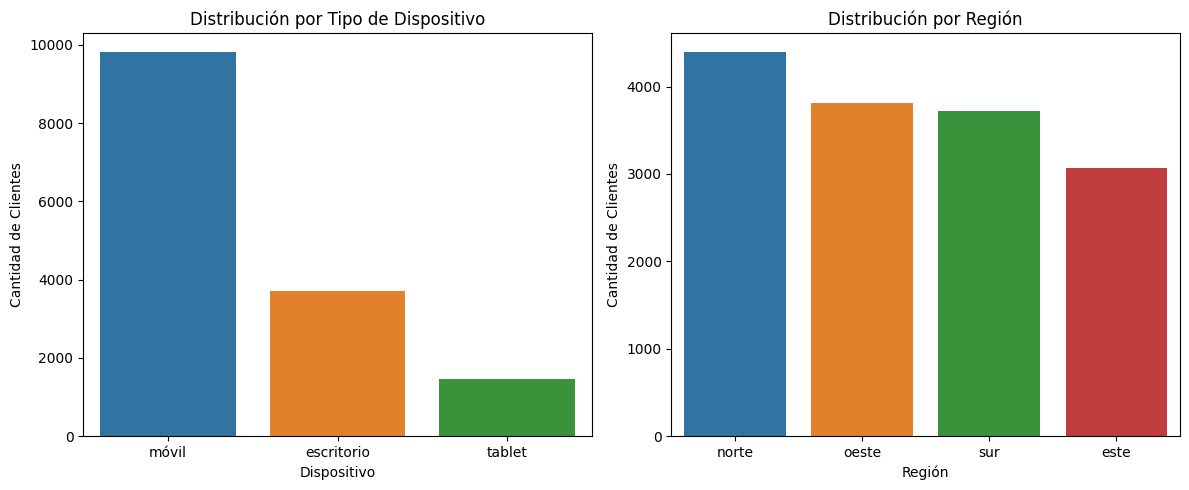

In [9]:
# Explorar variables categóricas y cómo se distribuyen
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Gráfico para tipo_dispositivo
sns.countplot(data=df, x='tipo_dispositivo', ax=axes[0], order=df['tipo_dispositivo'].value_counts().index)
axes[0].set_title('Distribución por Tipo de Dispositivo')
axes[0].set_xlabel('Dispositivo')
axes[0].set_ylabel('Cantidad de Clientes')

# Gráfico para region
sns.countplot(data=df, x='region', ax=axes[1], order=df['region'].value_counts().index)
axes[1].set_title('Distribución por Región')
axes[1].set_xlabel('Región')
axes[1].set_ylabel('Cantidad de Clientes')

plt.tight_layout()
plt.show()

**Diagnóstico inicial de variables categóricas**

- `tipo_dispositivo` — Se observa que la gran mayoría de los clientes se conectan a través de su móvil (9,818 usuarios), superando por mucho a los que usan escritorio de computadora o tablet.

- `region` — Se nota que los clientes están repartidos de forma bastante equilibrada entre las cuatro zonas. La región norte tiene la mayor cantidad de clientes (4,395), y la región este es la que tiene menos (3,069), pero las diferencias no son drásticas.

### Supuestos

- El análisis se realiza utilizando **todo el conjunto de datos disponible**.
- Los datos no presentan errores y están correctamente tipificados.
- Se utilizan distintos coeficientes según el tipo de variable:
  - **Pearson** asume relaciones lineales entre variables numéricas.
  - **Spearman** evalúa relaciones monótonas y no requiere normalidad.
  - **Punto biserial** se usa para relaciones numérica–binaria.
  - **Cramér (V)** se usa para asociaciones entre variables categóricas.

**Supuesto central:**  
Este análisis identifica relaciones entre variables o segmentos, pero no prueba causalidad.

## Sección 3 - Visualización de relaciones

Observamos cómo se relacionan las variables numéricas.

### Heatmap

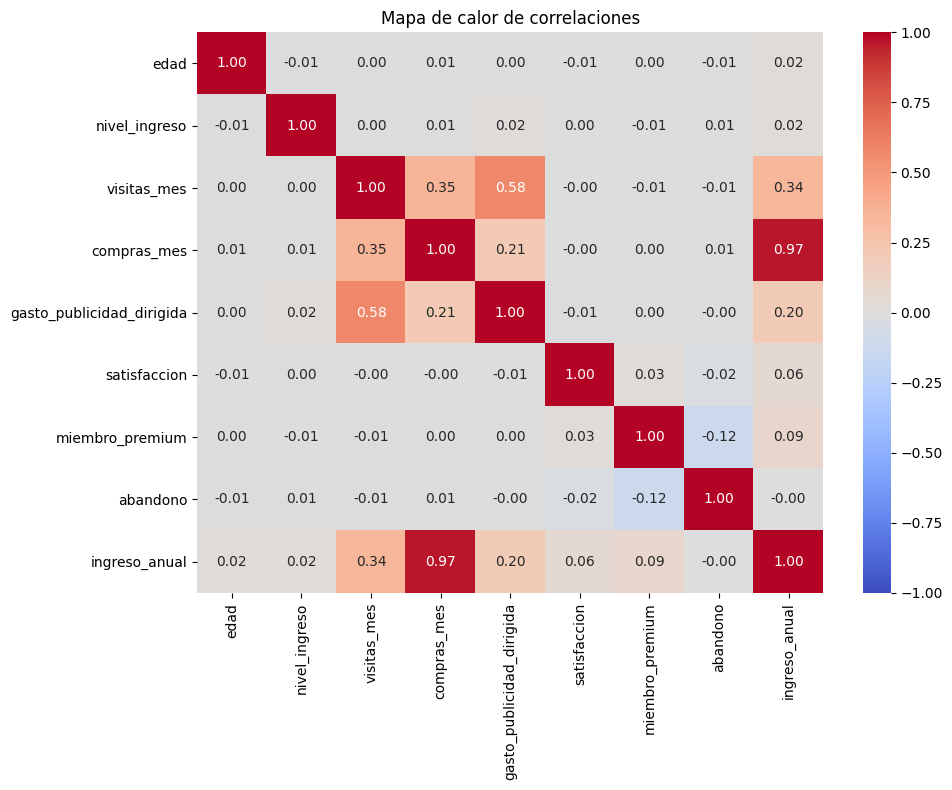

In [10]:
# Visualizar la matriz de correlación para identificar relaciones
columnas_numericas = df.select_dtypes(include=['int64', 'float64'])
matriz_corr = columnas_numericas.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(matriz_corr, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1)
plt.title('Mapa de calor de correlaciones')
plt.tight_layout()
plt.show()

**Observaciones generales (Heatmap)**

- Se observa una correlación positiva moderada a fuerte entre `gasto_publicidad_dirigida` y `visitas_mes`. Esto sugiere que la inversión publicitaria está directamente asociada con un mayor tráfico o visitas a la plataforma.

También se nota una correlación positiva entre las `visitas_mes` y las `compras_mes`.

Observaciones respecto a `ingreso_anual` 

- Presenta una correlación positiva muy fuerte con `compras_mes`. Esto indica claramente que el volumen de compras mensuales es el factor que está más fuertemente asociado con los ingresos generados.Además, muestra una correlación positiva moderada con `visitas_mes` y una relación más débil con `gasto_publicidad_dirigida`.

- Las variables demográficas (`edad`, `nivel_ingreso`) y de percepción (`satisfaccion`, `abandono`) prácticamente no presentan ninguna correlación lineal con los ingresos anuales.


### Scatterplot general

**Decisión:** Se decide no incluir el scatterplot general.

**Justificación:**

- Exceso de datos: Cruzar todas las variables numéricas con 15,000 registros genera un gráfico demasiado saturado, pesado y difícil de leer.

- Gráficos sin valor: El mapa de calor ya demostró que variables como la edad, los ingresos o la satisfacción no tienen relación con las demás. Graficarlas solo mostraría nubes de puntos sin sentido.

- Ir directo al grano: Resulta más práctico analizar y graficar únicamente los pares de variables que sí mostraron una correlación interesante (como las compras y los ingresos).

### Scatterplot para pares clave

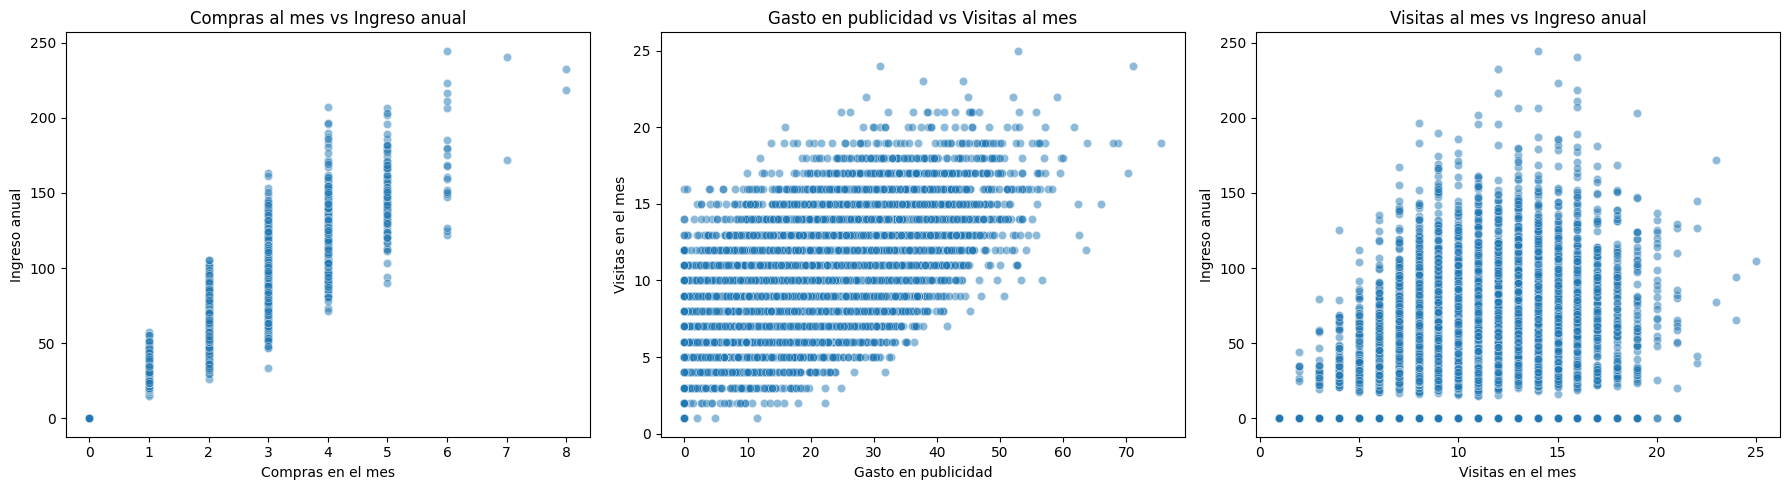

In [11]:
# Visualizar pares de variables con relaciones moderadas o fuertes
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Compras vs Ingreso Anual (Correlación muy fuerte)
sns.scatterplot(data=df, x='compras_mes', y='ingreso_anual', ax=axes[0], alpha=0.5)
axes[0].set_title('Compras al mes vs Ingreso anual')
axes[0].set_xlabel('Compras en el mes')
axes[0].set_ylabel('Ingreso anual')

# 2. Publicidad vs Visitas (Correlación moderada-fuerte)
sns.scatterplot(data=df, x='gasto_publicidad_dirigida', y='visitas_mes', ax=axes[1], alpha=0.5)
axes[1].set_title('Gasto en publicidad vs Visitas al mes')
axes[1].set_xlabel('Gasto en publicidad')
axes[1].set_ylabel('Visitas en el mes')

# 3. Visitas vs Ingreso Anual (Correlación moderada)
sns.scatterplot(data=df, x='visitas_mes', y='ingreso_anual', ax=axes[2], alpha=0.5)
axes[2].set_title('Visitas al mes vs Ingreso anual')
axes[2].set_xlabel('Visitas en el mes')
axes[2].set_ylabel('Ingreso anual')

plt.tight_layout()
plt.show()



**Observaciones iniciales (Scatterplot)**

**compras_mes vs ingreso_anual**

- Dirección: Positiva. A medida que aumenta el número de compras, el ingreso anual crece.

- Dispersión: Baja. Los datos están muy agrupados y siguen una tendencia lineal muy clara (casi formando líneas verticales por la naturaleza de los datos de compras).

- Outliers: Se identifican algunos puntos en la parte superior con ingresos mayores a 200 que podrían considerarse atípicos, aunque siguen la misma tendencia principal.

- Colinealidad: Existe una posible colinealidad muy fuerte, ya que el volumen de compras y los ingresos están midiendo prácticamente el mismo efecto de forma directa.

**gasto_publicidad_dirigida vs visitas_mes**

- Dirección: Positiva. Una mayor inversión en publicidad se asocia con un aumento en las visitas.

- Dispersión: Media. Se distingue una nube de puntos ascendente bien definida, pero con cierta anchura y variabilidad natural.

- Outliers: No se aprecian valores atípicos extremos que se salgan drásticamente del comportamiento general de la nube.

- Colinealidad: No se detectan problemas de colinealidad; son variables distintas con una correlación clara.

**visitas_mes vs ingreso_anual**

- Dirección: Positiva, pero con una pendiente mucho menos pronunciada.

- Dispersión: Alta. La nube de puntos es bastante abierta y esparcida, lo que indica que más visitas no siempre garantizan más ingresos.

- Outliers: Hay algunos clientes que generan ingresos altos a pesar de tener pocas visitas, los cuales resaltan como casos particulares fuera de la concentración principal.

- Colinealidad: No se observa colinealidad.


## Sección 4 - Coeficientes de correlación y evidencia numérica

En esta sección, se reportan coeficientes que respaldan los patrones
observados visualmente, utilizando el método adecuado según el tipo
de variables.


### Pearson / Spearman

In [12]:
# Calcular correlación entre variables relevantes (Pearson)
variables_clave = ['compras_mes', 'ingreso_anual', 'gasto_publicidad_dirigida', 'visitas_mes']

print("--- Correlación de Pearson ---")
display(df[variables_clave].corr(method='pearson'))


--- Correlación de Pearson ---


,compras_mes,ingreso_anual,gasto_publicidad_dirigida,visitas_mes
compras_mes,1.000000,0.967149,0.207528,0.353844
ingreso_anual,0.967149,1.000000,0.197483,0.337147
gasto_publicidad_dirigida,0.207528,0.197483,1.000000,0.578947
visitas_mes,0.353844,0.337147,0.578947,1.000000


In [13]:
# Calcular correlación entre variables relevantes (Spearman)
print("--- Correlación de Spearman ---")
display(df[variables_clave].corr(method='spearman'))


--- Correlación de Spearman ---


,compras_mes,ingreso_anual,gasto_publicidad_dirigida,visitas_mes
compras_mes,1.000000,0.967482,0.192511,0.332943
ingreso_anual,0.967482,1.000000,0.184999,0.320954
gasto_publicidad_dirigida,0.192511,0.184999,1.000000,0.559267
visitas_mes,0.332943,0.320954,0.559267,1.000000


**Observaciones de correlación**

**compras_mes vs ingreso_anual**

- Dirección: Positiva.

- Magnitud: Muy fuerte (0.97 en Pearson y Spearman), lo que indica una relación casi directa y proporcional.

- Posible colinealidad: Alta. Al tener un coeficiente tan cercano a 1, ambas variables están explicando prácticamente el mismo efecto económico, por lo que usarlas juntas en un modelo predictivo podría generar problemas de colinealidad.

**gasto_publicidad_dirigida vs visitas_mes**

- Dirección: Positiva.

- Magnitud: Moderada (0.58 en Pearson, 0.56 en Spearman), mostrando que la inversión en anuncios atrae tráfico pero no es el único motor.

- Posible colinealidad: Baja. Son variables independientes que miden conceptos distintos (inversión frente a tráfico).

### Punto-biserial

In [14]:
# Calcular correlación entre variables relevantes (incluyendo binarias)
variables_punto_biserial = ['ingreso_anual', 'compras_mes', 'miembro_premium', 'abandono']

print("--- Correlación Punto-Biserial ---")
display(df[variables_punto_biserial].corr(method='pearson'))


--- Correlación Punto-Biserial ---


,ingreso_anual,compras_mes,miembro_premium,abandono
ingreso_anual,1.000000,0.967149,0.093099,-0.002824
compras_mes,0.967149,1.000000,0.003431,0.008291
miembro_premium,0.093099,0.003431,1.000000,-0.120488
abandono,-0.002824,0.008291,-0.120488,1.000000


**Observaciones Punto-biserial**

**miembro_premium vs ingreso_anual**

- Relación: Dirección positiva y magnitud baja (0.09). Esto indica una tendencia muy débil a que los miembros premium tengan un ingreso anual ligeramente mayor, aunque la relación práctica es casi insignificante.

**abandono vs miembro_premium**

- Relación: Dirección negativa y magnitud baja (-0.12). Muestra que los clientes con membresía premium tienen una probabilidad ligeramente menor de abandonar la plataforma en comparación con los usuarios estándar.

### V de Cramér

In [15]:
# Función para calcular V de Cramér
import scipy.stats as stats

def cramers_v(confusion_matrix):
    chi2 = stats.chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    return np.sqrt(phi2 / min(k - 1, r - 1))


In [16]:
# Aplicar V de Cramér en variables relevantes
tabla_dispositivo_abandono = pd.crosstab(df['tipo_dispositivo'], df['abandono'])
print("V de Cramér (Tipo de dispositivo vs Abandono):", cramers_v(tabla_dispositivo_abandono))

tabla_region_abandono = pd.crosstab(df['region'], df['abandono'])
print("V de Cramér (Región vs Abandono):", cramers_v(tabla_region_abandono))

V de Cramér (Tipo de dispositivo vs Abandono): 0.007245190431994803
V de Cramér (Región vs Abandono): 0.015429712175030079


**Observaciones V de Cramér**

**tipo_dispositivo vs abandono**

- Asociación: Magnitud casi nula (0.007). Esto indica que no existe una relación significativa entre el tipo de dispositivo que utiliza el cliente y la probabilidad de que abandone la plataforma.

**region vs abandono**

- Asociación: Magnitud muy baja (0.015). Muestra que la región geográfica del usuario tampoco está asociada de forma relevante con el abandono del servicio.



## Sección 5 - Interpretación de resultados para el negocio



### **Hallazgo 1 — Relación entre el volumen de compras y el ingreso anual:**

**1) Evidencia visual:** El scatterplot de compras_mes vs ingreso_anual muestra una nube de puntos con una tendencia lineal ascendente muy marcada y de baja dispersión.

**2) Evidencia numérica:** Los coeficientes de Pearson y Spearman son de 0.97, indicando una correlación positiva y muy fuerte.

**3) Interpretación (no causal):** Existe una relación directa y casi proporcional entre la cantidad de compras mensuales que realiza un cliente y el ingreso anual que genera para la empresa.

**4) No podemos afirmar:** Que aumentar las compras de un usuario de forma forzada o artificial vaya a propiciar de manera directa un incremento proporcional en los ingresos totales sin tomar en cuenta el valor monetario de dichas transacciones.

**5) Implicación de negocio:** El equipo de crecimiento debe enfocar sus estrategias de retención y marketing en incentivar la frecuencia de compra (por ejemplo, mediante recordatorios personalizados o programas de lealtad), ya que este es el principal motor económico identificado en la plataforma.



### **Hallazgo 2 — Relación entre la inversión publicitaria y las visitas**

**1) Evidencia visual:** El scatterplot entre el gasto_publicidad_dirigida y las visitas_mes muestra una tendencia ascendente clara, con una dispersión moderada.

**2) Evidencia numérica:** Las correlaciones de Pearson y Spearman se sitúan en 0.58 y 0.56, respectivamente (asociación positiva y moderada).

**3) Interpretación (no causal):** Asignar mayor presupuesto a la publicidad dirigida se asocia con un incremento en el tráfico de visitas mensuales a la plataforma, aunque el tráfico también responde a otros canales o factores externos.

**4) No podemos afirmar:** Que todo el incremento en el tráfico web y las visitas provenga exclusivamente de las campañas de publicidad dirigida pagadas.

**5) Implicación de negocio:** La inversión en anuncios es eficaz para atraer tráfico y mantener la visibilidad de la plataforma, por lo que se recomienda mantener una asignación optimizada de presupuesto en las regiones y canales con mejor respuesta, evaluando siempre el retorno sobre la inversión (ROI) más allá de las meras visitas.



### **Hallazgo 3 — Relación entre la membresía premium y la retención**

**1) Evidencia visual:** No aplica directamente para visualización en scatterplot al tratarse de variables binarias cruzadas, pero se respalda con la matriz de correlación punto-biserial.

**2) Evidencia numérica:** El coeficiente de correlación entre miembro_premium y abandono es de -0.12 (correlación negativa y baja).

**3) Interpretación (no causal):** Los clientes que cuentan con una suscripción premium muestran una tendencia levemente menor a abandonar la plataforma en comparación con los usuarios estándar.

**4) No podemos afirmar:** Que adquirir una membresía premium elimine por completo el riesgo de abandono ni que sea el único factor determinante en la retención del usuario.

**5) Implicación de negocio:** El programa de membresía premium cumple un rol positivo en la retención. Por ello, el equipo de producto y retención debería analizar incentivos para convertir a más usuarios regulares en miembros premium, ayudando a disminuir la tasa de cancelación.

## Sección 6 - Limitaciones y próximos pasos

### **Limitaciones**

- **Correlación no implica causalidad:** Aunque se identificaron relaciones fuertes y estadísticamente significativas (como entre las compras mensuales y el ingreso anual), el análisis exploratorio no demuestra que una variable provoque de forma directa a la otra, ya que pueden influir factores de confusión o variables omitidas.
  
- **Alcance transversal del periodo:** El estudio se limita exclusivamente a los registros del año 2024 de la plataforma, por lo que no se evalúa la evolución temporal ni las posibles variaciones debidas a la estacionalidad a lo largo del tiempo.

- **Baja asociación en variables categóricas:** Las variables como la región geográfica o el tipo de dispositivo no muestran asociaciones lineales ni de Cramér relevantes con el abandono o los ingresos, lo que restringe su utilidad predictiva directa en modelos simples.

### **Próximos pasos** 

[Paso 1] - Probar segmentación adicional:

- Analizar el comportamiento de los clientes agrupándolos por rangos de edad o nivel de ingresos para detectar patrones específicos en diferentes grupos de usuarios.
  
- Segmentar la base de datos según el tipo de dispositivo y la región geográfica para comparar cómo varían las métricas clave de comportamiento entre distintos subgrupos.

[Paso 2]

- Profundizar en el análisis del ticket promedio y la frecuencia de compras mensuales por usuario para identificar oportunidades de negocio orientadas a incrementar el valor de los clientes.

[Paso 3]

- Evaluar el impacto de las campañas de publicidad dirigida por regiones geográficas para optimizar la asignación del presupuesto de marketing en función del tráfico generado.